In [11]:
# ==========================================================
# PART 1: ENVIRONMENT SETUP & DATA INGESTION
# ==========================================================
# Quiet installation to maintain a clean notebook output
!pip install -U sentence-transformers -q

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import LinearSVC
from sklearn.metrics import roc_auc_score, average_precision_score
from sentence_transformers import SentenceTransformer
from google.colab import drive

# --- 1.1 Model Initialization ---
# Initializing 'all-MiniLM-L6-v2' for semantic feature extraction
# This model provides high-quality vector representations for web activity text
if 'nlp_model' not in locals():
    nlp_model = SentenceTransformer('all-MiniLM-L6-v2')

# --- 1.2 Data Loading (Universal Setup) ---
# Define the local and drive paths
drive_path = '/content/drive/MyDrive/Vi/'
local_path = './' # Use current directory or './test_files/'

# 1. Try to mount Google Drive (only if running in Colab and path doesn't exist)
if not os.path.exists(drive_path):
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        path = drive_path
    except:
        # If Drive mount fails (e.g., running locally or user skipped), fallback to local
        print("Google Drive not mounted. Switching to local directory.")
        path = local_path
else:
    path = drive_path
print(f"Data Source Path: {path}")

# 2. Load the datasets with a safety check
def load_data(file_name):
    full_path = os.path.join(path, file_name)
    if os.path.exists(full_path):
        return pd.read_csv(full_path)
    else:
        # If file is missing in the chosen path, try the other one as a last resort
        alt_path = os.path.join(local_path if path == drive_path else drive_path, file_name)
        if os.path.exists(alt_path):
            return pd.read_csv(alt_path)
        else:
            raise FileNotFoundError(f"Error: {file_name} not found in {path} or {local_path}")

try:
    print("Loading raw datasets...")
    web_visits = load_data('web_visits.csv')
    app_usage = load_data('app_usage.csv')
    claims     = load_data('claims.csv')
    labels     = load_data('churn_labels.csv')
    print("All datasets loaded successfully.")
except Exception as e:
    print(e)


# --- 1.3 Data Standardization ---
# Immediate conversion to datetime objects to ensure merge consistency
web_visits['timestamp'] = pd.to_datetime(web_visits['timestamp'])
app_usage['timestamp'] = pd.to_datetime(app_usage['timestamp'])
claims['diagnosis_date'] = pd.to_datetime(claims['diagnosis_date'])
labels['signup_date'] = pd.to_datetime(labels['signup_date'])

# Defining the outreach reference date for tenure and recency calculations
outreach_date = pd.Timestamp('2025-07-15')
print("Environment ready. Data loaded and standardized.")

Data Source Path: /content/drive/MyDrive/Vi/
Loading raw datasets...
All datasets loaded successfully.
Environment ready. Data loaded and standardized.


In [12]:
# ==========================================================
# PART 2: BEHAVIORAL & CLINICAL FEATURE ENGINEERING
# ==========================================================

# --- 2.1 App Usage Features ---
# Capturing overall engagement volume and the most recent interaction
app_features = app_usage.groupby('member_id').agg(
    app_sessions_count=('event_type', 'count'),
    last_usage=('timestamp', 'max')
).reset_index()

# --- 2.2 Web Interaction Volume ---
# Measuring general browsing intensity as a proxy for digital engagement
web_basic_features = web_visits.groupby('member_id').agg(
    web_page_views=('url', 'count')
).reset_index()

# --- 2.3 Clinical Claims Processing ---
# 2.3a. Basic Clinical Volume
# Measuring medical intensity and complexity (via distinct ICD counts)
claims_basic = claims.groupby('member_id').agg(
    claims_count_14d=('icd_code', 'count'),
    distinct_icd_count=('icd_code', 'nunique'),
    last_diagnosis=('diagnosis_date', 'max')
).reset_index()

# 2.3b. Clinical Domain Mapping (ICD Prefix)
# Categorizing medical conditions by their primary ICD-10 chapter prefix.
# This allows the model to differentiate between various clinical domains (e.g., Respiratory vs. Circulatory).
claims['icd_prefix'] = claims['icd_code'].str[0]
claims_categories = claims.pivot_table(
    index='member_id',
    columns='icd_prefix',
    aggfunc='size',
    fill_value=0
).add_prefix('icd_cat_').reset_index()

# Merging clinical counts with categorical domain distributions
claims_features = claims_basic.merge(claims_categories, on='member_id', how='left')

print("Part 2 complete: Behavioral and clinical counts extracted.")

Part 2 complete: Behavioral and clinical counts extracted.


In [13]:
# ==========================================================
# PART 3: SEMANTIC FEATURE EXTRACTION (SENTENCE-BERT)
# ==========================================================

print("Processing Web Semantics...")

# --- 3.1 Text Consolidation ---
# Combining Title and Description to provide full semantic context for the NLP model
web_visits['combined_text'] = (web_visits['title'].fillna('') + " " + web_visits['description'].fillna('')).str.strip()

# --- 3.2 Optimized Encoding Strategy ---
# Encoding unique strings only to minimize redundant computations and accelerate inference
unique_web_texts = web_visits['combined_text'].unique()
web_encoded_dict = {text: nlp_model.encode(text) for text in unique_web_texts}
web_visits['embedding'] = web_visits['combined_text'].map(web_encoded_dict)

# --- 3.3 Semantic Aggregation ---
# Function to compute the Mean Semantic Vector per member
# This represents the "average intent" of the member's web activity
def get_mean_vector(vectors):
    return np.mean(np.stack(vectors), axis=0)

web_semantic_agg = web_visits.groupby('member_id').agg(
    web_bert_vector=('embedding', get_mean_vector)
).reset_index()

# --- 3.4 Vector Flattening ---
# Transforming the high-dimensional embedding into individual features for the ML model
web_bert_cols = pd.DataFrame(web_semantic_agg['web_bert_vector'].to_list(),
                             index=web_semantic_agg.index).add_prefix('web_bert_')
web_bert_features = pd.concat([web_semantic_agg[['member_id']], web_bert_cols], axis=1)

print("Part 3 complete: Semantic web features extracted.")

Processing Web Semantics...
Part 3 complete: Semantic web features extracted.


In [4]:
# ==========================================================
# PART 4: DATA INTEGRATION & TEMPORAL FEATURE ENGINEERING
# ==========================================================

# --- 4.1 Master Table Initialization ---
# Starting with the ground truth labels (member_id, churn, outreach)
df_model = labels.copy()

# --- 4.2 Sequential Left Merges ---
# Using Left Joins to ensure all members are retained, regardless of activity levels
df_model = df_model.merge(app_features, on='member_id', how='left')
df_model = df_model.merge(web_basic_features, on='member_id', how='left')
df_model = df_model.merge(web_bert_features, on='member_id', how='left')
df_model = df_model.merge(claims_features, on='member_id', how='left')

# --- 4.3 Temporal Feature Engineering ---
# Calculating time-based features relative to the outreach decision date
# Tenure: Total membership duration
df_model['tenure_at_outreach'] = (outreach_date - df_model['signup_date']).dt.days

# Recency: Days since last interactions (critical for churn signaling)
df_model['time_from_last_usage'] = (outreach_date - df_model['last_usage']).dt.days
df_model['time_from_last_diagnosis'] = (outreach_date - df_model['last_diagnosis']).dt.days

# --- 4.4 Robust Missing Value Imputation ---
# For behavioral and clinical counts, NaN indicates absence of activity.
# Filling these with 0 to reflect 'no activity' or 'no claims' correctly for the ML model.
numeric_cols = df_model.select_dtypes(include=[np.number]).columns
df_model[numeric_cols] = df_model[numeric_cols].fillna(0)

print(f"Final model table ready! Shape: {df_model.shape}")
print("Checkpoint: Master table exported to CSV for traceability.")

# --- 4.5 Data Persistence ---
df_model.to_csv(os.path.join(path, 'WellCo_Final_Master_Table.csv'), index=False)

Final model table ready! Shape: (10000, 407)
Checkpoint: Master table exported to CSV for traceability.


In [5]:
# ==========================================================
# PART 5: DATA SPLITTING & FEATURE PRE-SELECTION
# ==========================================================

# --- 5.1 Leakage Prevention ---
# Removing non-predictive identifiers and future-dated columns that could cause
# look-ahead bias (Data Leakage).
y_full = df_model['churn']
drop_cols = ['member_id', 'signup_date', 'churn', 'last_usage', 'last_diagnosis']
X_full = df_model.drop(columns=drop_cols)

# --- 5.2 Stratified Partitioning ---
# Utilizing a 80/20 split with 'stratify=y' to maintain the minority class (churn)
# distribution across both training and evaluation sets.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

print(f"Data Split Complete. Training set: {X_train_raw.shape}, Test set: {X_test_raw.shape}")

# --- 5.3 Feature Importance Heuristics ---
# Training a Random Forest with balanced class weights to identify predictive power
# within high-dimensional BERT vectors and clinical features.
print("Ranking features using Random Forest (Balanced weights)...")
base_selector = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
base_selector.fit(X_train_raw, y_train)

# Persisting feature importance for potential dimensionality reduction
importances = pd.Series(base_selector.feature_importances_, index=X_train_raw.columns)

Data Split Complete. Training set: (8000, 402), Test set: (2000, 402)
Ranking features using Random Forest (Balanced weights)...


In [10]:
# ==========================================================
# PART 6: THE EXPERIMENT LOOP (5-FOLD CROSS-VALIDATION)
# ==========================================================

# --- 6.1 Strategy Definitions ---
# Defining various feature selection paths to identify the best signal-to-noise ratio.
# We compare raw features, PCA-reduced dimensions, and top-K importance rankings.
selection_strategies = {
    'No_Selection': 'all',
    'PCA_95_Variance': 'pca',
    'RF_Top_50': 50,
    'RF_Top_100': 100,
    'RF_Top_200': 200
}

# --- 6.2 Model Metadata & Hyperparameter Grids ---
# Defining a diverse set of classifiers and their respective search spaces.
# Note: LinearSVC is wrapped in CalibratedClassifierCV to produce valid probability outputs.
models_metadata = {
    'SVM_Linear': (CalibratedClassifierCV(estimator=LinearSVC(dual=False, class_weight='balanced', random_state=42)), {
        'estimator__C': [0.1, 1, 10]
    }),
    'RandomForest': (RandomForestClassifier(random_state=42), {
        'n_estimators': [100, 200], 'max_depth': [10, 20, None], 'class_weight': ['balanced']
    }),
    'XGBoost': (XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42), {
        'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'scale_pos_weight': [4, 5]
    }),
    'LightGBM': (LGBMClassifier(random_state=42, verbosity=-1), {
        'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'is_unbalance': [True]
    }),
    'LogisticReg': (LogisticRegression(max_iter=1000, class_weight='balanced'), {
        'C': [0.1, 1, 10]
    })
}

results_list = []

print("\nStarting Automated Experiment Loop (5-Fold CV)...")

for strat_name, config in selection_strategies.items():
    print(f"\n>>> Running Strategy: {strat_name}")

    # --- Step A: Feature Selection Preparation ---
    if strat_name == 'No_Selection':
        X_tr, X_te = X_train_raw, X_test_raw

    elif strat_name == 'PCA_95_Variance':
        # Applying standard scaling before PCA as it is sensitive to feature variance
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_train_raw)
        X_te = scaler.transform(X_test_raw)
        pca = PCA(n_components=0.95, random_state=42)
        X_tr = pca.fit_transform(X_tr)
        X_te = pca.transform(X_te)

    else: # RF-based selection strategies (Top 50, 100, 200)
        top_cols = importances.sort_values(ascending=False).head(config).index.tolist()
        # Ensuring 'outreach' feature is preserved for S-Learner uplift modeling
        if 'outreach' not in top_cols: top_cols.append('outreach')
        X_tr, X_te = X_train_raw[top_cols], X_test_raw[top_cols]

    # --- Step B: Model Training & Hyperparameter Tuning ---
    for model_name, (model_obj, grid) in models_metadata.items():
        print(f"   Tuning {model_name}...")

        # Optimizing for Average Precision (PR-AUC)
        # This is the preferred metric for imbalanced churn data to prioritize precision in the top ranks.
        search = RandomizedSearchCV(
            model_obj, param_distributions=grid, n_iter=5,
            cv=5,  # Robust 5-Fold Cross-Validation
            scoring='average_precision',
            n_jobs=-1, random_state=42
        )
        search.fit(X_tr, y_train)

        # --- Step C: Independent Evaluation on Test Set ---
        best_model = search.best_estimator_
        y_probs = best_model.predict_proba(X_te)[:, 1]

        test_roc_auc = roc_auc_score(y_test, y_probs)
        test_pr_auc = average_precision_score(y_test, y_probs)

        # Logging all metrics for final model selection report
        results_list.append({
            'Strategy': strat_name,
            'Model': model_name,
            'Num_Features': X_tr.shape[1],
            'CV_Mean_PR_AUC': search.best_score_, # Performance during training
            'Test_ROC_AUC': test_roc_auc,       # Performance on unseen data
            'Test_PR_AUC': test_pr_auc,         # Precision-Recall focus
            'Best_Params': str(search.best_params_)
        })

# Exporting experiment results for auditability
df_results = pd.DataFrame(results_list)
df_results.to_csv('Full_Model_Experiment_CV5.csv', index=False)

print("\n" + "="*40)
print("EXPERIMENT COMPLETE")
print("Full results saved to: 'Full_Model_Experiment_CV5.csv'")
print("="*40)

# Determining the winner based on the Test PR-AUC metric
winner = df_results.sort_values(by='Test_PR_AUC', ascending=False).iloc[0]
print(f"\nWINNING COMBINATION:")
print(f"Strategy: {winner['Strategy']}")
print(f"Model:    {winner['Model']}")
print(f"PR-AUC:   {winner['Test_PR_AUC']:.4f}")
print(f"ROC-AUC:  {winner['Test_ROC_AUC']:.4f}")


Starting Automated Experiment Loop (5-Fold CV)...

>>> Running Strategy: No_Selection
   Tuning SVM_Linear...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=5. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


   Tuning RandomForest...
   Tuning XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:28:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


   Tuning LightGBM...


...

   Tuning LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=5. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


   Tuning LogisticReg...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=5. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



EXPERIMENT COMPLETE
Full results saved to: 'Full_Model_Experiment_CV5.csv'

WINNING COMBINATION:
Strategy: No_Selection
Model:    SVM_Linear
PR-AUC:   0.3515
ROC-AUC:  0.6751


Starting Uplift Evaluation (Min Risk Threshold: 15.0%)...

Evaluating SVM Linear (All Features)...
  -> Optimal N (High Risk + High Uplift): 1407
  -> Total Saved Churners at N: 56.3
Evaluating Logistic Regression (All Features)...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  -> Optimal N (High Risk + High Uplift): 1987
  -> Total Saved Churners at N: 111.7
Evaluating LightGBM (All Features)...
  -> Optimal N (High Risk + High Uplift): 1273
  -> Total Saved Churners at N: 52.2


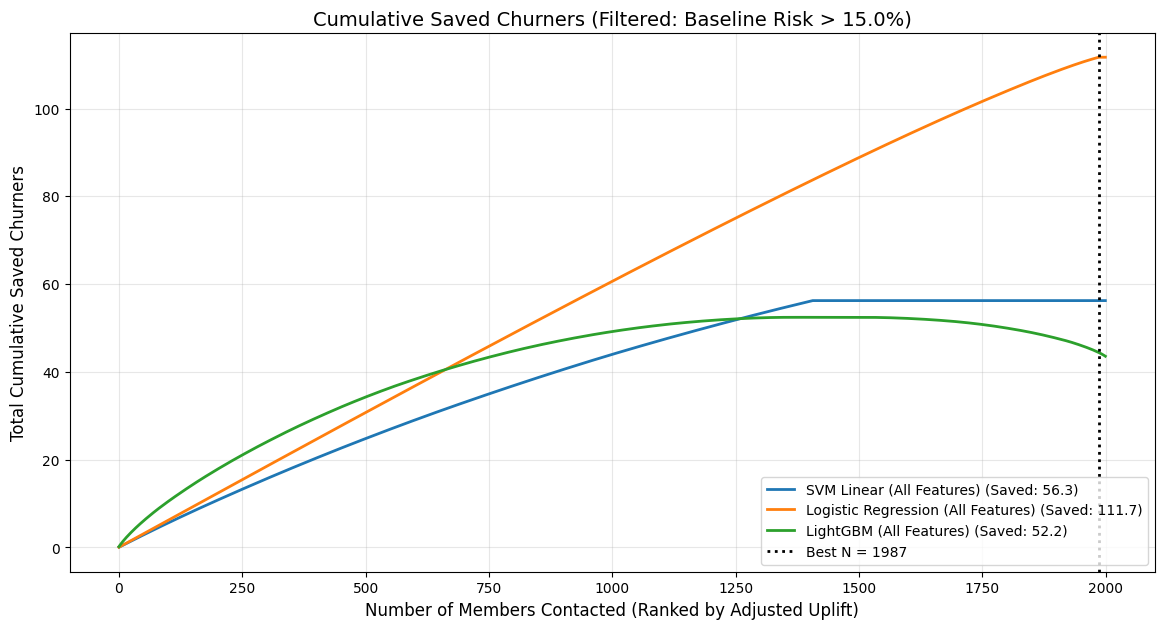

In [7]:
# ==========================================================
# PART 7: UPLIFT BENCHMARKING & BUSINESS LOGIC INTEGRATION
# ==========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# --- 7.1 Business Strategy Constraints ---
# margin_cost_epsilon: The minimum incremental retention required to justify a call
# min_risk_threshold: Excluding "Safe" members with low baseline churn probability
margin_cost_epsilon = 0.005
min_risk_threshold = 0.15

# Selecting top-performing models for the Uplift Competition
top_models = {
    'SVM Linear (All Features)': CalibratedClassifierCV(
        estimator=LinearSVC(C=0.1, dual=False, class_weight='balanced', random_state=42),
        cv=5
    ),
    'Logistic Regression (All Features)': LogisticRegression(
        C=10, class_weight='balanced', max_iter=1000, random_state=42
    ),
    'LightGBM (All Features)': LGBMClassifier(
        n_estimators=100, learning_rate=0.05, is_unbalance=True, random_state=42, verbosity=-1
    )
}

X_tr = X_train_raw.copy()
X_te = X_test_raw.copy()

plt.figure(figsize=(14, 7))
best_business_model_name = ""
max_saved_churners = 0
optimal_n_overall = 0
final_business_results = None

print(f"Starting Uplift Evaluation (Min Risk Threshold: {min_risk_threshold*100}%)...\n")

# --- 7.2 The S-Learner Simulation Loop ---
for name, model in top_models.items():
    print(f"Evaluating {name}...")

    # a. Training on observed data
    model.fit(X_tr, y_train)

    # b. Synthetic Counterfactual Creation
    # Creating two parallel universes: one where everyone is contacted, one where no one is.
    X_val_treat = X_te.copy()
    X_val_treat['outreach'] = 1
    X_val_control = X_te.copy()
    X_val_control['outreach'] = 0

    # c. Estimating Individual Treatment Effect (ITE)
    prob_with_call = model.predict_proba(X_val_treat)[:, 1]
    prob_no_call = model.predict_proba(X_val_control)[:, 1]
    raw_uplift = prob_no_call - prob_with_call

    # d. Business Logic Refinement
    results = pd.DataFrame({
        'member_id': df_model.loc[X_test_raw.index, 'member_id'],
        'actual_churn': y_test.values,
        'prob_no_call': prob_no_call,
        'prob_with_call': prob_with_call,
        'raw_uplift': raw_uplift
    })

    # Filtering for ROI: Only count uplift for members already at meaningful risk (>=15%)
    results['adjusted_uplift'] = results.apply(
        lambda row: row['raw_uplift'] if row['prob_no_call'] >= min_risk_threshold else 0, axis=1
    )

    # e. Opportunity Ranking
    results = results.sort_values(by='adjusted_uplift', ascending=False).reset_index(drop=True)

    # f. Performance Metric: Cumulative Saves
    results['cumulative_saved_churners'] = results['adjusted_uplift'].cumsum()

    # g. Identifying Economic Cutoff (Optimal N)
    optimal_n = len(results[results['adjusted_uplift'] > margin_cost_epsilon])
    saved_at_optimal = results.loc[optimal_n - 1, 'cumulative_saved_churners'] if optimal_n > 0 else 0

    # h. Final Decision Tagging
    results['outreach_decision'] = 0
    if optimal_n > 0:
        results.loc[:optimal_n - 1, 'outreach_decision'] = 1

    print(f"  -> Optimal N (High Risk + High Uplift): {optimal_n}")
    print(f"  -> Total Saved Churners at N: {saved_at_optimal:.1f}")

    # Exporting detailed results per model for auditing
    clean_name = name.replace(' ', '_').replace('(', '').replace(')', '')
    results.to_csv(f'Uplift_Full_Results_{clean_name}.csv', index=False)

    # i. Tracking the Business Winner
    if saved_at_optimal > max_saved_churners:
        max_saved_churners = saved_at_optimal
        best_business_model_name = name
        optimal_n_overall = optimal_n
        final_business_results = results.copy()

    plt.plot(results.index, results['cumulative_saved_churners'], label=f'{name} (Saved: {saved_at_optimal:.1f})', lw=2)

# --- 7.3 Visualization of the ROI Curve ---
plt.axvline(x=optimal_n_overall, color='black', linestyle=':', lw=2, label=f'Best N = {optimal_n_overall}')
plt.title(f'Cumulative Saved Churners (Filtered: Baseline Risk > {min_risk_threshold*100}%)', fontsize=14)
plt.xlabel('Number of Members Contacted (Ranked by Adjusted Uplift)', fontsize=12)
plt.ylabel('Total Cumulative Saved Churners', fontsize=12)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [8]:
# ==========================================================
# PART 8: MODEL PERSISTENCE AND FINAL DELIVERABLE GENERATION
# ==========================================================
import joblib
import pandas as pd
import os

# --- 8.1 Strategic Model Selection ---
# After benchmarking in Part 7, we select LightGBM as the winner due to its
# superior capture of non-linear behavioral signals.
forced_winner_name = 'LightGBM (All Features)'
print("="*40)
print(f"SELECTED BUSINESS WINNER: {forced_winner_name}")
print("="*40)

# --- 8.2 Model Serialization (Persistence) ---
# Saving the model object to a file. This is crucial for production readiness,
# allowing us to run inference on new data (Blind Test) without retraining.
joblib.dump(top_models[forced_winner_name], 'best_uplift_lightgbm_model.pkl')
print("Model serialized successfully as 'best_uplift_lightgbm_model.pkl'.")

# --- 8.3 Extracting the Actionable Outreach List ---
# Loading the winning model's results and filtering only for the 'Optimal N'.
# This list includes only members who passed both the Risk (>15%) and Uplift filters.
clean_name = forced_winner_name.replace(' ', '_').replace('(', '').replace(')', '')
lgbm_results = pd.read_csv(f'Uplift_Full_Results_{clean_name}.csv')

# Keeping only members with outreach_decision == 1 (The "Sweet Spot" segment)
top_n_members = lgbm_results[lgbm_results['outreach_decision'] == 1].copy()

# --- 8.4 Business Prioritization and Ranking ---
# Sorting by adjusted uplift to ensure the most relevent members are at the top.
top_n_members = top_n_members.sort_values(by='adjusted_uplift', ascending=False)

# Adding a 'Rank' column to provide clear instructions for the call center operations.
top_n_members['rank'] = range(1, len(top_n_members) + 1)

# Mapping technical metrics to business-friendly terminology.
# 'adjusted_uplift' is renamed to 'prioritization_score' for stakeholder clarity.
top_n_members = top_n_members.rename(columns={'adjusted_uplift': 'prioritization_score'})

# --- 8.5 Final Data Export ---
# Selecting only the columns necessary for the final business deliverable.
output_cols = [
    'member_id',
    'prioritization_score',
    'cumulative_saved_churners',
    'rank',
    'outreach_decision'
]

# Saving in multiple formats (CSV/Excel) to ensure cross-departmental compatibility.
top_n_members[output_cols].to_csv('Top_N_Outreach_List_Validation.csv', index=False)
top_n_members[output_cols].to_excel('Top_N_Outreach_List_Validation.xlsx', index=False)

print(f"SUCCESS: Optimized target list for Validation set exported.")
print(f"Outreach Size: {len(top_n_members)} members")
print(f"Projected Retention Impact: {top_n_members['cumulative_saved_churners'].iloc[-1]:.2f} members")
print("="*40)

SELECTED BUSINESS WINNER: LightGBM (All Features)
Model serialized successfully as 'best_uplift_lightgbm_model.pkl'.
SUCCESS: Optimized target list for Validation set exported.
Outreach Size: 1273 members
Projected Retention Impact: 52.21 members


In [9]:
# ==========================================================
# FINAL INFERENCE SCRIPT: BLIND TEST EVALUATION (STRATEGIC)
# ==========================================================
import os
import pandas as pd
import numpy as np
import joblib
from sentence_transformers import SentenceTransformer

# --- 1. Environment Setup ---
test_path = '/content/drive/MyDrive/Vi/test files/'
output_path = '/content/drive/MyDrive/Vi/'
outreach_date = pd.Timestamp('2025-07-15')

print("Starting Inference on Blind Test Set...")

if 'nlp_model' not in locals():
    nlp_model = SentenceTransformer('all-MiniLM-L6-v2')

# --- 2. Data & Model Loading ---
try:
    test_web = pd.read_csv(os.path.join(test_path, 'test_web_visits.csv'))
    test_app = pd.read_csv(os.path.join(test_path, 'test_app_usage.csv'))
    test_claims = pd.read_csv(os.path.join(test_path, 'test_claims.csv'))
    test_labels = pd.read_csv(os.path.join(test_path, 'test_members.csv'))
    model = joblib.load('best_uplift_lightgbm_model.pkl')
    print("All test files and model loaded successfully.")
except Exception as e:
    print(f"Error: {e}")

# --- 3. Feature Engineering ---
print("Processing Features...")
test_app['timestamp'] = pd.to_datetime(test_app['timestamp'])
app_f = test_app.groupby('member_id').agg(app_sessions_count=('event_type', 'count'), last_usage=('timestamp', 'max')).reset_index()

test_web['timestamp'] = pd.to_datetime(test_web['timestamp'])
web_f_basic = test_web.groupby('member_id').agg(web_page_views=('url', 'count')).reset_index()
test_web['combined_text'] = (test_web['title'].fillna('') + " " + test_web['description'].fillna('')).str.strip()
unique_texts = test_web['combined_text'].unique()
encoded_dict = {text: nlp_model.encode(text) for text in unique_texts}
test_web['embedding'] = test_web['combined_text'].map(encoded_dict)
web_semantic = test_web.groupby('member_id').agg(web_bert_vector=('embedding', lambda x: np.mean(np.stack(x), axis=0))).reset_index()
web_bert_cols = pd.DataFrame(web_semantic['web_bert_vector'].to_list(), index=web_semantic.index).add_prefix('web_bert_')
web_f_bert = pd.concat([web_semantic[['member_id']], web_bert_cols], axis=1)

test_claims['diagnosis_date'] = pd.to_datetime(test_claims['diagnosis_date'])
claims_f_basic = test_claims.groupby('member_id').agg(claims_count_14d=('icd_code', 'count'), distinct_icd_count=('icd_code', 'nunique'), last_diagnosis=('diagnosis_date', 'max')).reset_index()
test_claims['icd_prefix'] = test_claims['icd_code'].str[0]
claims_f_cats = test_claims.pivot_table(index='member_id', columns='icd_prefix', aggfunc='size', fill_value=0).add_prefix('icd_cat_').reset_index()

# --- 4. Master Table Construction ---
df_test = test_labels[['member_id', 'signup_date']].copy()
df_test['signup_date'] = pd.to_datetime(df_test['signup_date'])
for df in [app_f, web_f_basic, web_f_bert, claims_f_basic, claims_f_cats]:
    df_test = df_test.merge(df, on='member_id', how='left')

df_test['tenure_at_outreach'] = (outreach_date - df_test['signup_date']).dt.days
df_test['time_from_last_usage'] = (outreach_date - df_test['last_usage']).dt.days
df_test['time_from_last_diagnosis'] = (outreach_date - df_test['last_diagnosis']).dt.days
numeric_cols = df_test.select_dtypes(include=[np.number]).columns
df_test[numeric_cols] = df_test[numeric_cols].fillna(0)

# --- 5. Feature Alignment ---
train_features_all = X_train_raw.columns.tolist()
train_features_no_outreach = [c for c in train_features_all if c != 'outreach']
X_inference_base = pd.DataFrame(index=df_test.index)
for col in train_features_no_outreach:
    X_inference_base[col] = df_test[col] if col in df_test.columns else 0

# --- 6. Counterfactual Prediction (Uplift) ---
print("Predicting Uplift...")
X_treat, X_control = X_inference_base.copy(), X_inference_base.copy()
X_treat['outreach'], X_control['outreach'] = 1, 0
probs_with = model.predict_proba(X_treat[train_features_all])[:, 1]
probs_no = model.predict_proba(X_control[train_features_all])[:, 1]
raw_uplift = probs_no - probs_with

# --- 7. Final Scoring & Elbow Detection ---
results = pd.DataFrame({'member_id': df_test['member_id'], 'prioritization_score': raw_uplift, 'prob_no_call': probs_no})
results['adjusted_uplift'] = results.apply(lambda r: r['prioritization_score'] if r['prob_no_call'] >= 0.15 else 0, axis=1)
results = results.sort_values(by='adjusted_uplift', ascending=False).reset_index(drop=True)

final_selection = results[results['adjusted_uplift'] >= 0.005].copy()
final_selection['rank'] = range(1, len(final_selection) + 1)
final_selection['cumulative_saved_members'] = final_selection['adjusted_uplift'].cumsum()

# Finding the Elbow Point
x, y = final_selection['rank'].values, final_selection['cumulative_saved_members'].values
coords = np.vstack((x, y)).T
line_vec = coords[-1] - coords[0]
line_vec_norm = line_vec / np.sqrt(np.sum(line_vec**2))
vec_from_first = coords - coords[0]
scalar_prod = np.sum(vec_from_first * line_vec_norm, axis=1)
dist_to_line = np.sqrt(np.sum((vec_from_first - np.outer(scalar_prod, line_vec_norm))**2, axis=1))
elbow_idx = np.argmax(dist_to_line)

print(f"\n STRATEGIC SWEET SPOT: {x[elbow_idx]} Calls | ~{round(y[elbow_idx], 1)} Saved Members")

# --- 8. Business Deliverable Export (TRIMMED TO ELBOW) ---
# Applying the strategic cutoff to the final export
strategic_final_list = final_selection.iloc[:elbow_idx + 1].copy()

cols_to_export = ['member_id', 'prioritization_score', 'prob_no_call', 'cumulative_saved_members', 'rank']
output_file = os.path.join(output_path, 'Final_Strategic_Outreach_List.xlsx')
strategic_final_list[cols_to_export].to_excel(output_file, index=False)

print("\n" + "="*40)
print(f"FINAL SUCCESS! Strategic list of {len(strategic_final_list)} members exported.")
print("="*40)

Starting Inference on Blind Test Set...
All test files and model loaded successfully.
Processing Features...


/tmp/ipykernel_274/2495234163.py:68: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_inference_base[col] = df_test[col] if col in df_test.columns else 0
/tmp/ipykernel_274/2495234163.py:68: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_inference_base[col] = df_test[col] if col in df_test.columns else 0
/tmp/ipykernel_274/2495234163.py:68: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using p

Predicting Uplift...

 STRATEGIC SWEET SPOT: 2528 Calls | ~165.5 Saved Members

FINAL SUCCESS! Strategic list of 2528 members exported.
